In [1]:
import json
from collections import defaultdict

# --------------------------
# Step 1: Load replay JSON
# --------------------------
path = "/Users/marcomaluf/Desktop/Unfinished Projects/New RL/7eed5127-fe22-4ad9-8781-ede12842f2ab.replay.json"
with open(path, "r", encoding="utf-8") as f:
    replay = json.load(f)

frames = replay["network_frames"]["frames"]
objects = replay["objects"]
net_cache = replay["net_cache"]

print("Loaded replay with", len(frames), "frames")

# --------------------------
# Step 2: Build PRI stat stream map (shots, assists, goals, saves only)
# --------------------------
pri_entry = None
for entry in net_cache:
    oi = entry.get("object_ind")
    if oi is not None and objects[oi] == "TAGame.PRI_TA":
        pri_entry = entry
        break

if pri_entry is None:
    raise RuntimeError("Could not find TAGame.PRI_TA net cache in replay (PRI class).")

pri_stream_map = {}
for prop in pri_entry["properties"]:
    obj_ind = prop["object_ind"]
    stream_id = prop["stream_id"]
    pri_stream_map[stream_id] = objects[obj_ind]

stat_names = ["MatchShots", "MatchAssists", "MatchGoals", "MatchSaves"]
stat_streams = {sid: name for sid, name in pri_stream_map.items() if any(k in name for k in stat_names)}
print("Tracked PRI stat stream ids:", stat_streams)

# --------------------------
# Step 3: Map actor_id -> player_name
# --------------------------
def extract_name(attr):
    if not isinstance(attr, dict):
        return None
    if "Reservation" in attr and isinstance(attr["Reservation"], dict):
        if "name" in attr["Reservation"]:
            return attr["Reservation"]["name"]
    if "String" in attr and isinstance(attr["String"], str):
        return attr["String"]
    for v in attr.values():
        if isinstance(v, dict):
            if "name" in v and isinstance(v["name"], str):
                return v["name"]
            if "String" in v and isinstance(v["String"], str):
                return v["String"]
        if isinstance(v, str) and v and len(v) < 64:
            return v
    return None

actor_to_name = {}
for frame in frames:
    for ua in frame.get("updated_actors", []):
        aid = ua.get("actor_id")
        name = extract_name(ua.get("attribute", {}))
        if name:
            actor_to_name[aid] = name

print("Discovered", len(actor_to_name), "actors with names")

# --------------------------
# Step 4: Collect stat-change events (including initialization)
# --------------------------
stat_stream_ids = set(stat_streams.keys())
events = []  # raw stat property updates

for fi, frame in enumerate(frames):
    t = frame.get("time")
    for ua in frame.get("updated_actors", []):
        sid = ua.get("stream_id")
        if sid in stat_stream_ids:
            aid = ua.get("actor_id")
            prop = stat_streams[sid]
            attr = ua.get("attribute", {})
            val = None
            if isinstance(attr, dict):
                for k in ("Int", "Byte", "Float"):
                    if k in attr:
                        val = attr[k]
                        break
                if val is None:
                    def find_num(x):
                        if isinstance(x, (int, float)):
                            return x
                        if isinstance(x, dict):
                            for vv in x.values():
                                r = find_num(vv)
                                if r is not None:
                                    return r
                        return None
                    val = find_num(attr)
            events.append({
                "frame": fi,
                "time": t,
                "actor_id": aid,
                "player_name": actor_to_name.get(aid, f"Actor{aid}"),
                "property": prop,
                "value": val
            })

print("Collected", len(events), "raw stat events")

# --------------------------
# Step 5: Separate initialization from increments
# --------------------------
series = defaultdict(list)  # (actor_id, property) -> list of (frame, time, value)
for e in events:
    key = (e["actor_id"], e["property"])
    series[key].append((e["frame"], e["time"], e["value"]))

initializations = []
increments = []

for key, vals in series.items():
    prev_val = None
    for frame, time, v in vals:
        if prev_val is None and v is not None:
            # first time this property is set for this actor
            initializations.append({
                "frame": frame,
                "time": time,
                "actor_id": key[0],
                "player_name": actor_to_name.get(key[0], f"Actor{key[0]}"),
                "property": key[1],
                "value": v
            })
        elif prev_val is not None and v is not None:
            delta = v - prev_val
            if delta != 0:
                increments.append({
                    "frame": frame,
                    "time": time,
                    "actor_id": key[0],
                    "player_name": actor_to_name.get(key[0], f"Actor{key[0]}"),
                    "property": key[1],
                    "delta": delta,
                    "new_value": v
                })
        prev_val = v

# --------------------------
# Step 6: Print results
# --------------------------
print("\n=== Initialization events (first time stats are seen) ===")
for init in initializations:
    print(f"Frame {init['frame']}: {init['player_name']} {init['property']} initialized to {init['value']}")

print("\n=== Stat increments (shots, saves, assists, goals) ===")
for inc in increments:
    if inc["delta"] > 0:
        print(f"Frame {inc['frame']}: {inc['player_name']} +{inc['delta']} {inc['property']} (new={inc['new_value']})")


Loaded replay with 9934 frames
Tracked PRI stat stream ids: {78: 'TAGame.PRI_TA:MatchShots', 79: 'TAGame.PRI_TA:MatchSaves', 80: 'TAGame.PRI_TA:MatchAssists', 81: 'TAGame.PRI_TA:MatchGoals'}
Discovered 8 actors with names
Collected 389 raw stat events

=== Initialization events (first time stats are seen) ===
Frame 626: TeeZee TAGame.PRI_TA:MatchShots initialized to 1
Frame 652: Mu3 TAGame.PRI_TA:MatchSaves initialized to 1
Frame 2065: Nissan-no-Ghost TAGame.PRI_TA:MatchShots initialized to 1
Frame 2143: TeeZee TAGame.PRI_TA:MatchGoals initialized to 1
Frame 2151: Nissan-no-Ghost TAGame.PRI_TA:MatchAssists initialized to 1
Frame 2886: Mu3 TAGame.PRI_TA:MatchShots initialized to 1
Frame 2908: Mu3 TAGame.PRI_TA:MatchGoals initialized to 1
Frame 2915: JJ TAGame.PRI_TA:MatchAssists initialized to 1
Frame 3500: JJ TAGame.PRI_TA:MatchSaves initialized to 1
Frame 4059: HxFF TAGame.PRI_TA:MatchShots initialized to 1
Frame 4092: Nissan-no-Ghost TAGame.PRI_TA:MatchSaves initialized to 1
Frame 45

In [8]:
initializations

[{'frame': 626,
  'time': 25.999228,
  'actor_id': 5,
  'player_name': 'TeeZee',
  'property': 'TAGame.PRI_TA:MatchShots',
  'value': 1},
 {'frame': 652,
  'time': 26.889605,
  'actor_id': 37,
  'player_name': 'Mu3',
  'property': 'TAGame.PRI_TA:MatchSaves',
  'value': 1},
 {'frame': 2065,
  'time': 75.44407,
  'actor_id': 27,
  'player_name': 'Nissan-no-Ghost',
  'property': 'TAGame.PRI_TA:MatchShots',
  'value': 1},
 {'frame': 2143,
  'time': 78.11807,
  'actor_id': 5,
  'player_name': 'TeeZee',
  'property': 'TAGame.PRI_TA:MatchGoals',
  'value': 1},
 {'frame': 2151,
  'time': 78.390045,
  'actor_id': 27,
  'player_name': 'Nissan-no-Ghost',
  'property': 'TAGame.PRI_TA:MatchAssists',
  'value': 1},
 {'frame': 2886,
  'time': 105.83192,
  'actor_id': 37,
  'player_name': 'Mu3',
  'property': 'TAGame.PRI_TA:MatchShots',
  'value': 1},
 {'frame': 2908,
  'time': 106.59505,
  'actor_id': 37,
  'player_name': 'Mu3',
  'property': 'TAGame.PRI_TA:MatchGoals',
  'value': 1},
 {'frame': 2915

In [9]:
import json
from collections import defaultdict

def extract_scoreboard_changes(path):
    """
    Given a Rocket League replay JSON (from rrrocket/boxcars),
    return a list of scoreboard-related changes (shots, saves, assists, goals),
    including both initializations and increments.
    
    Each element in the returned list is a dict with keys:
      - frame
      - time
      - actor_id
      - player_name
      - property   (e.g. MatchShots, MatchAssists)
      - value      (for initializations)
      - delta      (for increments, optional)
      - new_value  (for increments, optional)
    """

    # --------------------------
    # Load replay JSON
    # --------------------------
    with open(path, "r", encoding="utf-8") as f:
        replay = json.load(f)

    frames = replay["network_frames"]["frames"]
    objects = replay["objects"]
    net_cache = replay["net_cache"]

    # --------------------------
    # Build PRI stat stream map
    # --------------------------
    pri_entry = None
    for entry in net_cache:
        oi = entry.get("object_ind")
        if oi is not None and objects[oi] == "TAGame.PRI_TA":
            pri_entry = entry
            break

    if pri_entry is None:
        raise RuntimeError("Could not find TAGame.PRI_TA net cache in replay (PRI class).")

    pri_stream_map = {}
    for prop in pri_entry["properties"]:
        obj_ind = prop["object_ind"]
        stream_id = prop["stream_id"]
        pri_stream_map[stream_id] = objects[obj_ind]

    stat_names = ["MatchShots", "MatchAssists", "MatchGoals", "MatchSaves"]
    stat_streams = {sid: name for sid, name in pri_stream_map.items() if any(k in name for k in stat_names)}

    # --------------------------
    # Map actor_id -> player_name
    # --------------------------
    def extract_name(attr):
        if not isinstance(attr, dict):
            return None
        if "Reservation" in attr and isinstance(attr["Reservation"], dict):
            if "name" in attr["Reservation"]:
                return attr["Reservation"]["name"]
        if "String" in attr and isinstance(attr["String"], str):
            return attr["String"]
        for v in attr.values():
            if isinstance(v, dict):
                if "name" in v and isinstance(v["name"], str):
                    return v["name"]
                if "String" in v and isinstance(v["String"], str):
                    return v["String"]
            if isinstance(v, str) and v and len(v) < 64:
                return v
        return None

    actor_to_name = {}
    for frame in frames:
        for ua in frame.get("updated_actors", []):
            aid = ua.get("actor_id")
            name = extract_name(ua.get("attribute", {}))
            if name:
                actor_to_name[aid] = name

    # --------------------------
    # Collect raw stat property updates
    # --------------------------
    stat_stream_ids = set(stat_streams.keys())
    events = []  # raw stat updates

    for fi, frame in enumerate(frames):
        t = frame.get("time")
        for ua in frame.get("updated_actors", []):
            sid = ua.get("stream_id")
            if sid in stat_stream_ids:
                aid = ua.get("actor_id")
                prop = stat_streams[sid]
                attr = ua.get("attribute", {})
                val = None
                if isinstance(attr, dict):
                    for k in ("Int", "Byte", "Float"):
                        if k in attr:
                            val = attr[k]
                            break
                    if val is None:
                        def find_num(x):
                            if isinstance(x, (int, float)):
                                return x
                            if isinstance(x, dict):
                                for vv in x.values():
                                    r = find_num(vv)
                                    if r is not None:
                                        return r
                            return None
                        val = find_num(attr)
                events.append({
                    "frame": fi,
                    "time": t,
                    "actor_id": aid,
                    "player_name": actor_to_name.get(aid, f"Actor{aid}"),
                    "property": prop,
                    "value": val
                })

    # --------------------------
    # Build initializations and increments
    # --------------------------
    series = defaultdict(list)  # (actor_id, property) -> list of (frame, time, value)
    for e in events:
        key = (e["actor_id"], e["property"])
        series[key].append((e["frame"], e["time"], e["value"]))

    changes = []

    for key, vals in series.items():
        prev_val = None
        for frame, time, v in vals:
            if prev_val is None and v is not None:
                # initialization
                changes.append({
                    "frame": frame,
                    "time": time,
                    "actor_id": key[0],
                    "player_name": actor_to_name.get(key[0], f"Actor{key[0]}"),
                    "property": key[1],
                    "value": v,
                    "event_type": "init"
                })
            elif prev_val is not None and v is not None:
                delta = v - prev_val
                if delta != 0:
                    changes.append({
                        "frame": frame,
                        "time": time,
                        "actor_id": key[0],
                        "player_name": actor_to_name.get(key[0], f"Actor{key[0]}"),
                        "property": key[1],
                        "delta": delta,
                        "new_value": v,
                        "event_type": "increment"
                    })
            prev_val = v

    # --------------------------
    # Return combined list sorted by frame
    # --------------------------
    changes.sort(key=lambda x: x["frame"])
    return changes


In [10]:
scoreboard = extract_scoreboard_changes('7eed5127-fe22-4ad9-8781-ede12842f2ab.replay.json')
scoreboard

[{'frame': 626,
  'time': 25.999228,
  'actor_id': 5,
  'player_name': 'TeeZee',
  'property': 'TAGame.PRI_TA:MatchShots',
  'value': 1,
  'event_type': 'init'},
 {'frame': 652,
  'time': 26.889605,
  'actor_id': 37,
  'player_name': 'Mu3',
  'property': 'TAGame.PRI_TA:MatchSaves',
  'value': 1,
  'event_type': 'init'},
 {'frame': 2065,
  'time': 75.44407,
  'actor_id': 27,
  'player_name': 'Nissan-no-Ghost',
  'property': 'TAGame.PRI_TA:MatchShots',
  'value': 1,
  'event_type': 'init'},
 {'frame': 2143,
  'time': 78.11807,
  'actor_id': 5,
  'player_name': 'TeeZee',
  'property': 'TAGame.PRI_TA:MatchGoals',
  'value': 1,
  'event_type': 'init'},
 {'frame': 2151,
  'time': 78.390045,
  'actor_id': 27,
  'player_name': 'Nissan-no-Ghost',
  'property': 'TAGame.PRI_TA:MatchAssists',
  'value': 1,
  'event_type': 'init'},
 {'frame': 2886,
  'time': 105.83192,
  'actor_id': 37,
  'player_name': 'Mu3',
  'property': 'TAGame.PRI_TA:MatchShots',
  'value': 1,
  'event_type': 'init'},
 {'frame

### GET IT TO ONLY TRACK THE BOOST AMOUNTS PROPERLY, AND THEN MANUALLY USE THAT TO FIGURE OUT BOOST USAGE, PICKUPS, ETC. BY DOING THE TIME-LAG THING I THOUGHT OF ON MY WALK

In [2]:
import json
import numpy as np
import re

# Input: parsed replay JSON (from rrrocket/boxcars)
REPLAY_JSON = "7eed5127-fe22-4ad9-8781-ede12842f2ab.replay.json"

# -------------------
# Load JSON
# -------------------
with open(REPLAY_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

frames  = data["network_frames"]["frames"]
objects = data["objects"]
num_frames = len(frames)

# -------------------
# Helpers to find object indices
# -------------------
def find_index(substr):
    substr = substr.lower()
    return next((i for i, s in enumerate(objects) if substr in s.lower()), None)

playername_idx = find_index("playerreplicationinfo:playername")
playerrep_idx  = find_index("engine.pawn:playerreplicationinfo")
vehicle_idx    = find_index("carcomponent_ta:vehicle")

# boost property object IDs
boost_obj_indices = [i for i, s in enumerate(objects)
                     if "carcomponent_boost" in s.lower() and
                        ("replicatedboost" in s.lower() or "currentboostamount" in s.lower())]
if not boost_obj_indices:
    boost_obj_indices = [i for i, s in enumerate(objects)
                         if "boost" in s.lower() and "amount" in s.lower()]

assert playername_idx is not None
assert playerrep_idx is not None
assert vehicle_idx is not None

# -------------------
# Value extractors
# -------------------
def find_actor_field(attr):
    if isinstance(attr, dict):
        for k, v in attr.items():
            if k.lower() == "actor" and isinstance(v, int):
                return v
            res = find_actor_field(v)
            if res is not None:
                return res
    elif isinstance(attr, list):
        for e in attr:
            res = find_actor_field(e)
            if res is not None:
                return res
    return None

def extract_string(attr):
    if isinstance(attr, str):
        return attr
    if isinstance(attr, dict):
        for v in attr.values():
            s = extract_string(v)
            if s: return s
    if isinstance(attr, list):
        for e in attr:
            s = extract_string(e)
            if s: return s
    return None

def extract_boost_amount(attr):
    if not isinstance(attr, dict):
        return None
    for k, v in attr.items():
        if isinstance(v, dict) and "boost_amount" in v:
            return float(v["boost_amount"])
        if k.lower() in ("float","double","byte","int","short") and isinstance(v,(int,float)):
            return float(v)
    if isinstance(attr, dict):
        for v in attr.values():
            amt = extract_boost_amount(v)
            if amt is not None: return amt
    if isinstance(attr, list):
        for e in attr:
            amt = extract_boost_amount(e)
            if amt is not None: return amt
    return None

# -------------------
# Mappings
# -------------------
pri_actor_to_name = {}   # stable
car_actor_to_pri  = {}   # dynamic
boostcomp_to_car  = {}   # dynamic

# Pending boost updates that arrived before mapping was known
pending = []  # list of (frame, car_actor, amount)

# Player boost arrays (filled later)
player_arrays = {}

# -------------------
# Walk frames
# -------------------
for fi, frame in enumerate(frames):

    # --- handle new actors (cars etc.)
    for na in frame.get("new_actors", []):
        obj = objects[na["object_id"]]
        if "car_ta" in obj.lower():
            car_actor_to_pri[na["actor_id"]] = None

    # --- handle updates
    for upd in frame.get("updated_actors", []):
        aid   = upd["actor_id"]
        objid = upd["object_id"]
        attr  = upd.get("attribute", {})

        if objid == playername_idx:  # Player name
            nm = extract_string(attr)
            if nm:
                pri_actor_to_name[aid] = nm
                if nm not in player_arrays:
                    player_arrays[nm] = np.full((num_frames,), np.nan)

        elif objid == playerrep_idx:  # Car -> PRI link
            pri = find_actor_field(attr)
            if pri is not None:
                car_actor_to_pri[aid] = pri

        elif objid == vehicle_idx:    # BoostComp -> Car link
            car_actor = find_actor_field(attr)
            if car_actor is not None:
                boostcomp_to_car[aid] = car_actor

        elif objid in boost_obj_indices or \
             "replicatedboost" in objects[objid].lower() or \
             "currentboostamount" in objects[objid].lower():
            amt = extract_boost_amount(attr)
            if amt is not None:
                car_actor = boostcomp_to_car.get(aid)
                if car_actor is not None:
                    pri = car_actor_to_pri.get(car_actor)
                    if pri is not None and pri in pri_actor_to_name:
                        pname = pri_actor_to_name[pri]
                        player_arrays.setdefault(pname, np.full((num_frames,), np.nan))
                        player_arrays[pname][fi] = amt
                    else:
                        # mapping not known yet → buffer it
                        pending.append((fi, car_actor, amt))

    # --- resolve pending boosts if mappings are now available
    still_pending = []
    for f, car, amt in pending:
        pri = car_actor_to_pri.get(car)
        if pri is not None and pri in pri_actor_to_name:
            pname = pri_actor_to_name[pri]
            player_arrays.setdefault(pname, np.full((num_frames,), np.nan))
            player_arrays[pname][f] = amt
        else:
            still_pending.append((f, car, amt))
    pending = still_pending

    # --- clean up deleted actors
    for dead in frame.get("deleted_actors", []):
        car_actor_to_pri.pop(dead, None)
        boostcomp_to_car.pop(dead, None)

# -------------------
# Forward fill arrays so every frame has boost
# -------------------
for p, arr in player_arrays.items():
    last = np.nan
    for i in range(len(arr)):
        if not np.isnan(arr[i]):
            last = arr[i]
        else:
            arr[i] = last if not np.isnan(last) else np.nan


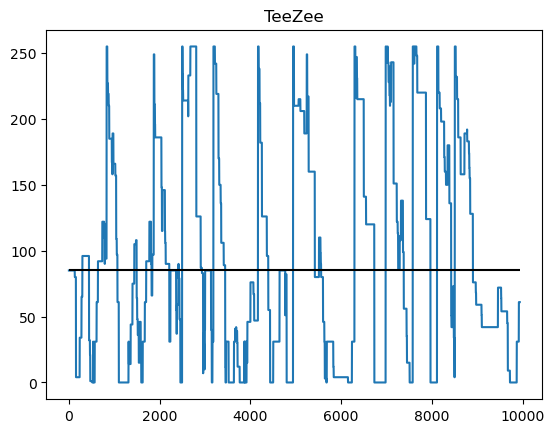

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
         22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
         33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
         44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
         55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
         66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
         77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
         88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
         99,  100,  101,  102,  103,  104,  105,  106,  107,  108,  109,
        110,  111,  112,  113,  114,  115,  116,  117,  118,  119,  120,
        121,  122,  123,  124,  125,  126,  127,  128, 2236, 2237, 2238,
       2239, 2240, 2241, 2242, 2243, 2244, 2245, 2246, 2247, 2248, 2249,
       2250, 2251, 2252, 2253, 2254, 2255, 2256, 2

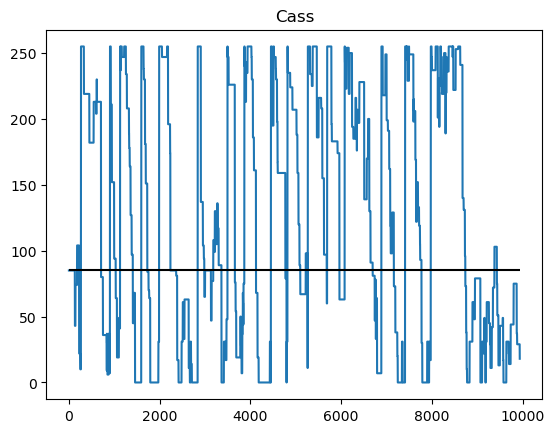

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
         22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
         33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
         44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
         55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
         66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
         77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
         88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
         99,  100,  101,  102,  103,  104,  105,  106,  107,  108,  109,
        110,  111,  112,  113,  114,  115,  116,  117,  118,  119,  120,
        121,  122,  123,  124,  125,  126,  127,  128,  129,  130, 2235,
       2236, 2237, 2238, 2239, 2240, 2241, 2242, 2243, 2244, 2245, 2246,
       2247, 2248, 2249, 2250, 2251, 2252, 2253, 2

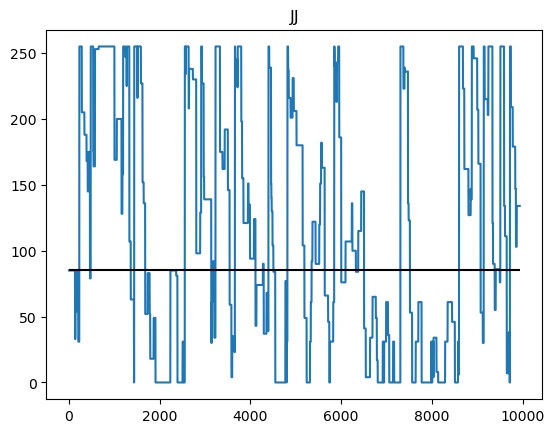

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
         22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
         33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
         44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
         55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
         66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
         77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
         88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
         99,  100,  101,  102,  103,  104,  105,  106,  107,  108,  109,
        110,  111,  112,  113,  114,  115,  116,  117,  118,  119,  120,
        121,  122,  123,  124,  125,  126,  127,  128,  129,  130,  131,
        132,  133,  134,  176,  177,  178,  179,  180,  181,  182,  183,
        184,  185,  186,  187,  188,  189,  190,  

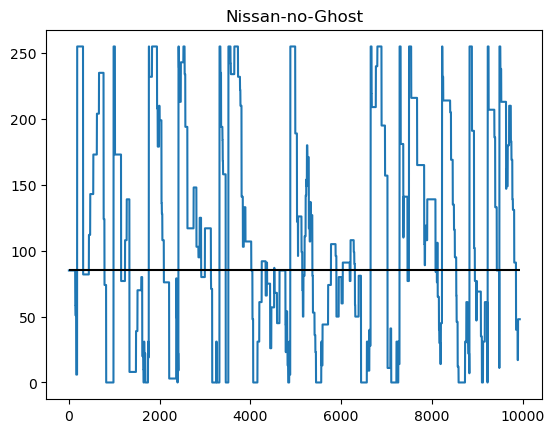

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
         22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
         33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
         44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
         55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
         66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
         77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
         88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
         99,  100,  101,  102,  103,  104,  105,  106,  107,  108,  109,
        110,  111,  112,  113,  114,  115,  116,  117,  118,  119,  120,
        121,  122,  123,  124,  125,  126,  127,  128,  129,  130,  131,
        132,  133,  134,  135,  136,  137,  138, 4017, 4018, 4019, 4020,
       4021, 4022, 4023, 4024, 4025, 4026, 4027, 4

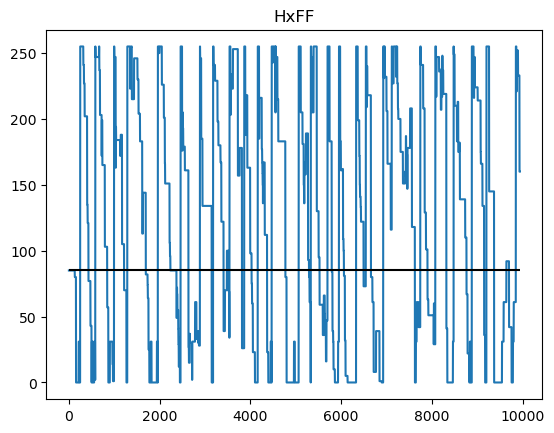

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
         22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
         33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
         44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
         55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
         66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
         77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
         88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
         99,  100,  101,  102,  103,  104,  105,  106,  107,  108,  109,
        110,  111,  112,  113,  114,  115,  116,  117,  118,  119,  120,
        121,  122,  123,  124,  125,  126,  127,  128, 2235, 2236, 2237,
       2238, 2239, 2240, 2241, 2242, 2243, 2244, 2245, 2246, 2247, 2248,
       2249, 2250, 2251, 2252, 2253, 2254, 2255, 2

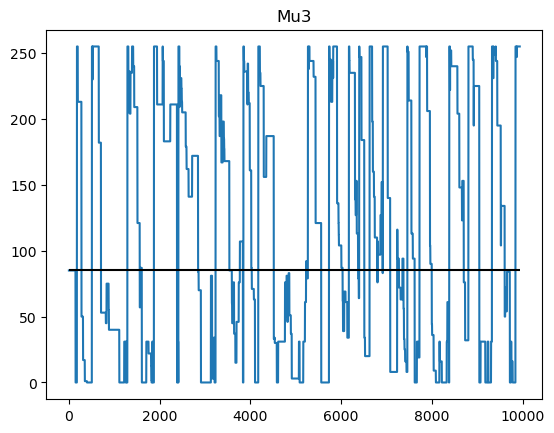

(array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
         11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
         22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
         33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
         44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
         55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
         66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
         77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
         88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
         99,  100,  101,  102,  103,  104,  105,  106,  107,  108,  109,
        110,  111,  112,  113,  114,  115,  116,  117,  118,  119,  120,
        121,  122,  123,  124,  125,  126,  127,  128,  129,  130,  131,
        132,  133,  134,  135,  136,  137,  138,  139,  140,  141,  142,
        143,  144,  145, 3534, 3535, 3536, 3537, 3

In [19]:
import matplotlib.pyplot as plt

for k, v in player_arrays.items():

    plt.title(f'{k}')
    plt.plot(v)
    plt.hlines(y=85, xmin=0, xmax=len(v), colors='black')
    plt.show()
    print(np.where(v == 85))

In [ ]:
import json
import numpy as np
import re

def extract_player_boost_arrays(replay_json_path: str) -> dict[str, np.ndarray]:
    """
    Parse a Boxcars/rrrocket JSON replay and return a dict of per-player boost arrays.
    
    Each entry in the dict is {player_name: np.array}, where the array has length equal
    to the number of frames in the replay and contains the boost amount (0–255) at each frame.
    
    Handles:
      - car respawns (actor IDs change)
      - delayed PlayerReplicationInfo updates
      - forward-fills boost values across frames
    """
    
    # -------------------
    # Load JSON
    # -------------------
    with open(replay_json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    frames  = data["network_frames"]["frames"]
    objects = data["objects"]
    num_frames = len(frames)

    # -------------------
    # Find relevant object indices
    # -------------------
    def find_index(substr):
        substr = substr.lower()
        return next((i for i, s in enumerate(objects) if substr in s.lower()), None)

    playername_idx = find_index("playerreplicationinfo:playername")
    playerrep_idx  = find_index("engine.pawn:playerreplicationinfo")
    vehicle_idx    = find_index("carcomponent_ta:vehicle")

    # boost property object IDs
    boost_obj_indices = [i for i, s in enumerate(objects)
                         if "carcomponent_boost" in s.lower() and
                            ("replicatedboost" in s.lower() or "currentboostamount" in s.lower())]
    if not boost_obj_indices:
        boost_obj_indices = [i for i, s in enumerate(objects)
                             if "boost" in s.lower() and "amount" in s.lower()]

    # -------------------
    # Helpers
    # -------------------
    def find_actor_field(attr):
        if isinstance(attr, dict):
            for k, v in attr.items():
                if k.lower() == "actor" and isinstance(v, int):
                    return v
                res = find_actor_field(v)
                if res is not None:
                    return res
        elif isinstance(attr, list):
            for e in attr:
                res = find_actor_field(e)
                if res is not None:
                    return res
        return None

    def extract_string(attr):
        if isinstance(attr, str):
            return attr
        if isinstance(attr, dict):
            for v in attr.values():
                s = extract_string(v)
                if s: return s
        if isinstance(attr, list):
            for e in attr:
                s = extract_string(e)
                if s: return s
        return None

    def extract_boost_amount(attr):
        if not isinstance(attr, dict):
            return None
        for k, v in attr.items():
            if isinstance(v, dict) and "boost_amount" in v:
                return float(v["boost_amount"])
            if k.lower() in ("float","double","byte","int","short") and isinstance(v,(int,float)):
                return float(v)
        if isinstance(attr, dict):
            for v in attr.values():
                amt = extract_boost_amount(v)
                if amt is not None: return amt
        if isinstance(attr, list):
            for e in attr:
                amt = extract_boost_amount(e)
                if amt is not None: return amt
        return None

    # -------------------
    # State mappings
    # -------------------
    pri_actor_to_name = {}   # stable
    car_actor_to_pri  = {}   # dynamic
    boostcomp_to_car  = {}   # dynamic

    pending = []             # buffered boosts: (frame, car_actor, amount)
    player_arrays = {}       # output

    # -------------------
    # Walk frames
    # -------------------
    for fi, frame in enumerate(frames):
        # new actors
        for na in frame.get("new_actors", []):
            obj = objects[na["object_id"]]
            if "car_ta" in obj.lower():
                car_actor_to_pri[na["actor_id"]] = None

        # updates
        for upd in frame.get("updated_actors", []):
            aid   = upd["actor_id"]
            objid = upd["object_id"]
            attr  = upd.get("attribute", {})

            if objid == playername_idx:  # Player name
                nm = extract_string(attr)
                if nm:
                    pri_actor_to_name[aid] = nm
                    if nm not in player_arrays:
                        player_arrays[nm] = np.full((num_frames,), np.nan)

            elif objid == playerrep_idx:  # Car -> PRI
                pri = find_actor_field(attr)
                if pri is not None:
                    car_actor_to_pri[aid] = pri

            elif objid == vehicle_idx:    # BoostComp -> Car
                car_actor = find_actor_field(attr)
                if car_actor is not None:
                    boostcomp_to_car[aid] = car_actor

            elif objid in boost_obj_indices or \
                 "replicatedboost" in objects[objid].lower() or \
                 "currentboostamount" in objects[objid].lower():
                amt = extract_boost_amount(attr)
                if amt is not None:
                    car_actor = boostcomp_to_car.get(aid)
                    if car_actor is not None:
                        pri = car_actor_to_pri.get(car_actor)
                        if pri is not None and pri in pri_actor_to_name:
                            pname = pri_actor_to_name[pri]
                            player_arrays.setdefault(pname, np.full((num_frames,), np.nan))
                            player_arrays[pname][fi] = amt
                        else:
                            # buffer it until mapping known
                            pending.append((fi, car_actor, amt))

        # resolve pending
        still_pending = []
        for f, car, amt in pending:
            pri = car_actor_to_pri.get(car)
            if pri is not None and pri in pri_actor_to_name:
                pname = pri_actor_to_name[pri]
                player_arrays.setdefault(pname, np.full((num_frames,), np.nan))
                player_arrays[pname][f] = amt
            else:
                still_pending.append((f, car, amt))
        pending = still_pending

        # clean up deleted actors
        for dead in frame.get("deleted_actors", []):
            car_actor_to_pri.pop(dead, None)
            boostcomp_to_car.pop(dead, None)

    # -------------------
    # Forward fill
    # -------------------
    for p, arr in player_arrays.items():
        last = np.nan
        for i in range(len(arr)):
            if not np.isnan(arr[i]):
                last = arr[i]
            else:
                arr[i] = last if not np.isnan(last) else np.nan

    return player_arrays


In [12]:
boost_arrays = extract_player_boost_arrays('7eed5127-fe22-4ad9-8781-ede12842f2ab.replay.json')

In [13]:
boost_arrays

{'TeeZee': array([85., 85., 85., ..., 61., 61., 61.]),
 'Cass': array([85., 85., 85., ..., 29., 18., 18.]),
 'JJ': array([ 85.,  85.,  85., ..., 134., 134., 134.]),
 'Nissan-no-Ghost': array([85., 85., 85., ..., 48., 48., 48.]),
 'HxFF': array([ 85.,  85.,  85., ..., 160., 160., 160.]),
 'Mu3': array([ 85.,  85.,  85., ..., 255., 255., 255.])}

In [5]:
import json
from collections import defaultdict

def extract_scoreboard_timeline(path):
    """
    Parse a Rocket League replay JSON and return a timeline of scoreboard changes.
    Includes initializations (first seen values) and increments for:
    shots, assists, goals, saves, and score.
    
    Returns:
        changes (list[dict]): Each dict has keys:
            - frame
            - time
            - actor_id
            - player_name
            - property (e.g. MatchShots)
            - event_type ('init' or 'increment')
            - value (for init)
            - delta (for increment)
            - new_value (for increment)
    """
    # --------------------------
    # Step 1: Load replay JSON
    # --------------------------
    with open(path, "r", encoding="utf-8") as f:
        replay = json.load(f)

    frames = replay["network_frames"]["frames"]
    objects = replay["objects"]
    net_cache = replay["net_cache"]

    # --------------------------
    # Step 2: Find PRI net cache and map stat stream IDs
    # --------------------------
    pri_entry = None
    for entry in net_cache:
        oi = entry.get("object_ind")
        if oi is not None and objects[oi] == "TAGame.PRI_TA":
            pri_entry = entry
            break

    if pri_entry is None:
        raise RuntimeError("Could not find TAGame.PRI_TA net cache in replay (PRI class).")

    pri_stream_map = {}
    for prop in pri_entry["properties"]:
        obj_ind = prop["object_ind"]
        stream_id = prop["stream_id"]
        pri_stream_map[stream_id] = objects[obj_ind]

    stat_names = ["MatchShots", "MatchAssists", "MatchGoals", "MatchSaves", "MatchScore"]
    stat_streams = {sid: name for sid, name in pri_stream_map.items() if any(k in name for k in stat_names)}

    # --------------------------
    # Step 3: Build actor_id -> player_name map
    # --------------------------
    def extract_name(attr):
        if not isinstance(attr, dict):
            return None
        if "Reservation" in attr and isinstance(attr["Reservation"], dict):
            if "name" in attr["Reservation"]:
                return attr["Reservation"]["name"]
        if "String" in attr and isinstance(attr["String"], str):
            return attr["String"]
        for v in attr.values():
            if isinstance(v, dict):
                if "name" in v and isinstance(v["name"], str):
                    return v["name"]
                if "String" in v and isinstance(v["String"], str):
                    return v["String"]
            if isinstance(v, str) and v and len(v) < 64:
                return v
        return None

    actor_to_name = {}
    for frame in frames:
        for ua in frame.get("updated_actors", []):
            aid = ua.get("actor_id")
            name = extract_name(ua.get("attribute", {}))
            if name:
                actor_to_name[aid] = name

    # --------------------------
    # Step 4: Gather all raw PRI stat updates
    # --------------------------
    stat_stream_ids = set(stat_streams.keys())
    events = []

    for fi, frame in enumerate(frames):
        t = frame.get("time")
        for ua in frame.get("updated_actors", []):
            sid = ua.get("stream_id")
            if sid in stat_stream_ids:
                aid = ua.get("actor_id")
                prop = stat_streams[sid]
                attr = ua.get("attribute", {})
                val = None
                if isinstance(attr, dict):
                    for k in ("Int", "Byte", "Float"):
                        if k in attr:
                            val = attr[k]
                            break
                    if val is None:
                        def find_num(x):
                            if isinstance(x, (int, float)):
                                return x
                            if isinstance(x, dict):
                                for vv in x.values():
                                    r = find_num(vv)
                                    if r is not None:
                                        return r
                            return None
                        val = find_num(attr)
                events.append({
                    "frame": fi,
                    "time": t,
                    "actor_id": aid,
                    "player_name": actor_to_name.get(aid, f"Actor{aid}"),
                    "property": prop,
                    "value": val
                })

    # --------------------------
    # Step 5: Derive initializations and increments
    # --------------------------
    series = defaultdict(list)
    for e in events:
        key = (e["actor_id"], e["property"])
        series[key].append((e["frame"], e["time"], e["value"]))

    changes = []
    for key, vals in series.items():
        prev_val = None
        for frame, time, v in vals:
            if prev_val is None and v is not None:
                changes.append({
                    "frame": frame,
                    "time": time,
                    "actor_id": key[0],
                    "player_name": actor_to_name.get(key[0], f"Actor{key[0]}"),
                    "property": key[1],
                    "value": v,
                    "event_type": "init"
                })
            elif prev_val is not None and v is not None:
                delta = v - prev_val
                if delta != 0:
                    changes.append({
                        "frame": frame,
                        "time": time,
                        "actor_id": key[0],
                        "player_name": actor_to_name.get(key[0], f"Actor{key[0]}"),
                        "property": key[1],
                        "delta": delta,
                        "new_value": v,
                        "event_type": "increment"
                    })
            prev_val = v

    # --------------------------
    # Step 6: Sort and return
    # --------------------------
    changes.sort(key=lambda x: x["frame"])
    return changes

scoreboard_timeline = extract_scoreboard_timeline('7eed5127-fe22-4ad9-8781-ede12842f2ab.replay.json')
scoreboard_timeline

[{'frame': 182,
  'time': 10.753228,
  'actor_id': 5,
  'player_name': 'TeeZee',
  'property': 'TAGame.PRI_TA:MatchScore',
  'value': 2,
  'event_type': 'init'},
 {'frame': 238,
  'time': 12.672772,
  'actor_id': 37,
  'player_name': 'Mu3',
  'property': 'TAGame.PRI_TA:MatchScore',
  'value': 2,
  'event_type': 'init'},
 {'frame': 297,
  'time': 14.697704,
  'actor_id': 37,
  'player_name': 'Mu3',
  'property': 'TAGame.PRI_TA:MatchScore',
  'delta': 2,
  'new_value': 4,
  'event_type': 'increment'},
 {'frame': 320,
  'time': 15.485669,
  'actor_id': 27,
  'player_name': 'Nissan-no-Ghost',
  'property': 'TAGame.PRI_TA:MatchScore',
  'value': 2,
  'event_type': 'init'},
 {'frame': 326,
  'time': 15.691687,
  'actor_id': 37,
  'player_name': 'Mu3',
  'property': 'TAGame.PRI_TA:MatchScore',
  'delta': 10,
  'new_value': 14,
  'event_type': 'increment'},
 {'frame': 358,
  'time': 16.785576,
  'actor_id': 13,
  'player_name': 'Cass',
  'property': 'TAGame.PRI_TA:MatchScore',
  'value': 2,
  